In [1]:
import numpy as np
import importlib
from matplotlib import rc
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap

from scipy.ndimage import laplace

# Set up matplotlib configuration
rc("font", family="serif")
rc("pgf", texsystem="pdflatex")
rc("text", usetex=True)
rc("text.latex", preamble=r"\usepackage{amssymb}")
rc("text.latex", preamble=r"\usepackage[T1,T2A]{fontenc}")
rc("text.latex", preamble=r"\usepackage[utf8]{inputenc}")
rc("text.latex", preamble=r"\usepackage[english,russian]{babel}")

# List of modules to iterate over
modules = ['mex_4_5', 'mex_4_7', 'mex_6_5', 'mex_7_8', 'mex_8_5', 'mex_9_8']

def basic_vp_plots(module_name, iter):
    module = importlib.import_module(f"{module_name}.config")
    
    # Get the setup function and constants
    setup_model_and_geometry = getattr(module, 'setup_model_and_geometry')
    PATH_DATA_DSUB = getattr(module, 'PATH_DATA_DSUB')
    TMAX = getattr(module, 'TMAX')
    OUTPUT_DIRS = getattr(module, 'OUTPUT_DIRS')
    NBL = getattr(module, 'NBL')
    
    # Set up model and geometry
    model, dataset, _ = setup_model_and_geometry(PATH_DATA_DSUB, iter=iter)
    dataset._dt_r = model.critical_dt
    dataset._t_max_r = TMAX
    dataset.resample_on()
    
    # Load gradient data
    grad_u0 = np.load(f"{OUTPUT_DIRS['images']}/vp_iter_{iter}.npy")
    
    # Create figure
    fig, axs = plt.subplots(1, 1, figsize=(3, 4), dpi=150)
    # fig.suptitle(f"Module: {module_name}", fontsize=16)

    
    # titles = ['Gradient D0', 'Gradient U0', 'Imaginary Part (-U0 + D0)']

    h = axs.imshow(grad_u0.T, vmin=0.5, vmax=5.5, cmap='jet', 
                    extent=[0, grad_u0.shape[0]*0.03*5, grad_u0.shape[1]*0.03*5, 0])
    # ax.set_title(title)
    axs.set_xlabel("Расстояние, м")
    axs.set_ylabel("Глубина, м")
        # ax.grid()
    
    plt.tight_layout()
    # plt.savefig(f"{module_name}_gradients_plot.png", dpi=300, bbox_inches='tight')
    plt.show()

def laplace_grad_plots(module_name):

    # Dynamically import the module
    module = importlib.import_module(f"{module_name}.config")
    
    # Get the setup function and constants
    setup_model_and_geometry = getattr(module, 'setup_model_and_geometry')
    PATH_DATA_DSUB = getattr(module, 'PATH_DATA_DSUB')
    TMAX = getattr(module, 'TMAX')
    OUTPUT_DIRS = getattr(module, 'OUTPUT_DIRS')
    NBL = getattr(module, 'NBL')
    
    # Set up model and geometry
    model, dataset, _, _ = setup_model_and_geometry(0)
    dataset._dt_r = model.critical_dt
    dataset._t_max_r = TMAX
    dataset.resample_on()
    
    # Load gradient data
    grad_u0 = np.load(f"{OUTPUT_DIRS['gradients']}/grad_full_u_0.npy")
    grad_d0 = np.load(f"{OUTPUT_DIRS['gradients']}/grad_full_d_0.npy")
    grad_c0 = np.load(f"{OUTPUT_DIRS['gradients']}/grad_full_c_0.npy")
    
    # Create figure
    fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=150)
    # fig.suptitle(f"Module: {module_name}", fontsize=16)
    
    glmax = max([np.quantile(laplace(el), 0.975) for el in [grad_u0, grad_d0]])
    grad_u0 = laplace(grad_u0)
    grad_d0 = laplace(grad_d0)

    imag0 = -grad_u0 + grad_d0
    
    # titles = ['Gradient D0', 'Gradient U0', 'Imaginary Part (-U0 + D0)']
    
    # for gr, ax, title in zip([grad_d0, grad_u0, imag0], axs, titles):
    for gr, ax in zip([grad_d0, grad_u0, imag0], axs):
        h = ax.imshow(gr.T, vmin=-glmax, vmax=glmax, cmap='gray', 
                        extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
        # ax.set_title(title)
        ax.set_xlabel("Расстояние, м")
        ax.set_ylabel("Глубина, м")
        # ax.grid()
    
    plt.tight_layout()
    # plt.savefig(f"{module_name}_gradients_plot.png", dpi=300, bbox_inches='tight')
    plt.show()



In [ ]:
from matplotlib.animation import FuncAnimation

def animate_vp(module_name, n_iters=100, interval=200, vmin=0.5, vmax=6.5):
    module = importlib.import_module(f"{module_name}.config")
    
    # Get constants
    setup_model_and_geometry = getattr(module, 'setup_model_and_geometry')
    PATH_DATA_DSUB = getattr(module, 'PATH_DATA_DSUB')
    TMAX = getattr(module, 'TMAX')
    OUTPUT_DIRS = getattr(module, 'OUTPUT_DIRS')

    # Set up model and dataset once (for dt, tmax)
    model, dataset, _ = setup_model_and_geometry(PATH_DATA_DSUB, iter=0)
    dataset._dt_r = model.critical_dt
    dataset._t_max_r = TMAX
    dataset.resample_on()
    
    # Load first frame to get shape
    grad0 = np.load(f"{OUTPUT_DIRS['images']}/vp_iter_0.npy")

    fig, ax = plt.subplots(figsize=(3, 4), dpi=150)
    im = ax.imshow(grad0.T, vmin=vmin, vmax=vmax, cmap="jet",
                   extent=[0, grad0.shape[0]*0.03*5, grad0.shape[1]*0.03*5, 0])
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")
    title = ax.set_title("Iteration 0")

    # Update function for animation
    def update(frame):
        grad = np.load(f"{OUTPUT_DIRS['images']}/vp_iter_{frame}.npy")
        im.set_data(grad.T)
        title.set_text(f"Iteration {frame}")
        return im, title

    ani = FuncAnimation(fig, update, frames=range(n_iters+1),
                        interval=interval, blit=False, repeat=False)

    plt.close(fig)  # prevent double display in Jupyter

    # Export to HTML5 video
    return ani.to_html5_video()

In [6]:
from IPython.display import HTML

html_anim = animate_vp("mex_4_5", n_iters=99)
HTML(html_anim)

Operator `initdamp` ran in 0.01 s


In [ ]:
for i in range(60, 80):
    basic_vp_plots(modules[0], i)

In [ ]:
# Process all modules
for module_name in modules:
    # basic_grad_plots(module_name)
    laplace_grad_plots(module_name)

In [35]:
d_syn = np.load(f"mex_4_5/forward_snaps/recon_gather_{10}.npy")
print(d_syn.shape)

(13225, 49)


In [36]:
module = importlib.import_module(f"mex_4_5.config")
PATH_DATA_DPLUS = getattr(module, 'PATH_DATA_DPLUS')
# Get constants
setup_model_and_geometry = getattr(module, 'setup_model_and_geometry')
model, dataset, _ = setup_model_and_geometry(PATH_DATA_DPLUS, iter=98)
dataset.dt_r = model.critical_dt
dataset.t_max_r = 40.0
dataset.resample_on()
d_obs = dataset[10][0]

Operator `initdamp` ran in 0.01 s


In [37]:
print(np.quantile(d_obs, 0.99))
print(np.quantile(d_syn, 0.99))
scale_factor = np.sqrt(np.sum(d_obs.ravel()**2))/np.sqrt(np.sum(d_syn.ravel()**2))
print(scale_factor)

0.0005124485955803598
0.00027067374
1.6372923791072158


In [38]:
d_syn /= np.linalg.norm(d_syn, axis=0)
d_obs /= np.linalg.norm(d_obs, axis=1).reshape(-1, 1)

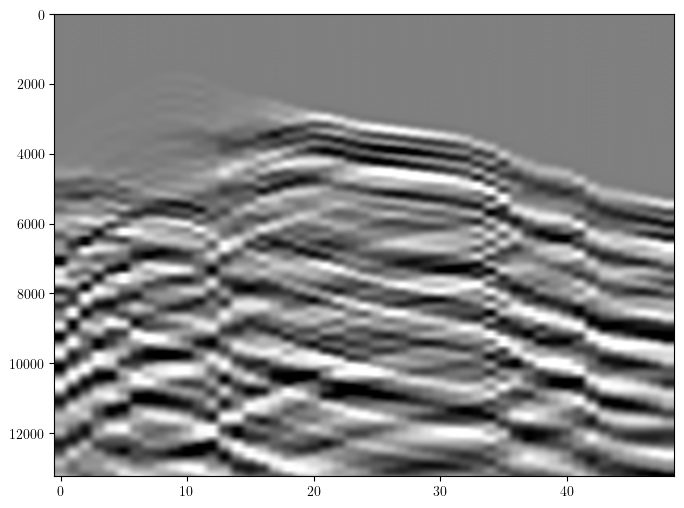

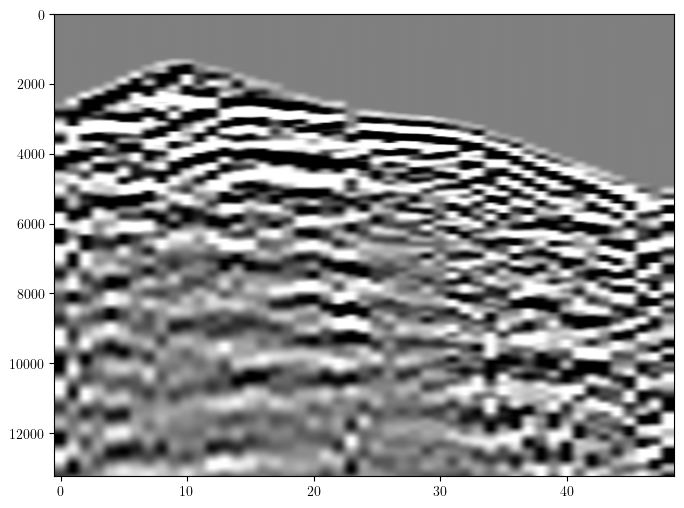

In [39]:
from matplotlib import pyplot as plt
qa = 0.02
plt.imshow(-d_syn, aspect='auto', vmin=-qa, vmax=qa, cmap='gray')
plt.show()
plt.imshow(d_obs.T*2, aspect='auto', vmin=-qa, vmax=qa, cmap='gray')
plt.show()

In [ ]:
model, dataset, dataset_sub, velmodel = setup_model_and_geometry(0)

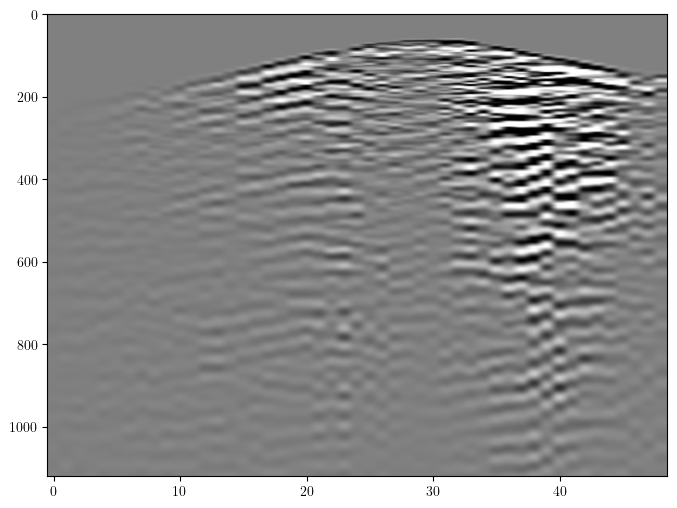

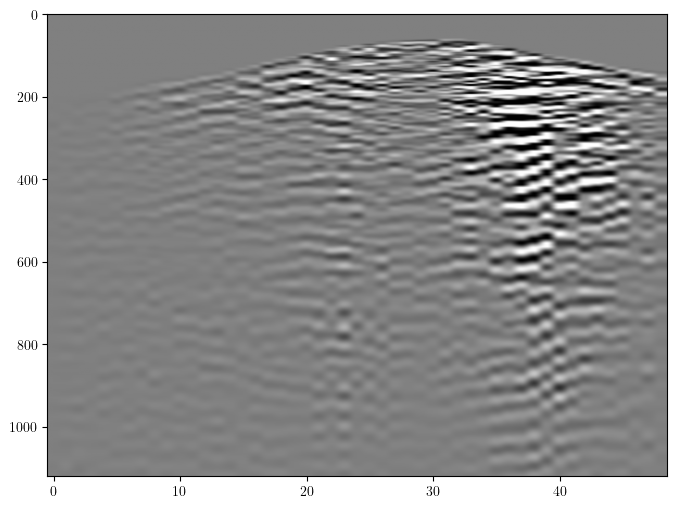

In [68]:
N = 31
dplus = dataset[N][0]
dsub = dataset_sub[N][0]
from matplotlib import pyplot as plt
qa = 0.001
plt.imshow(dplus.T, aspect='auto', vmin=-qa, vmax=qa, cmap='gray')
plt.show()
plt.imshow(dsub.T, aspect='auto', vmin=-qa, vmax=qa, cmap='gray')
plt.show()